# Comparaison de modèles de prévision de la demande pour la supply chain (classification)

## Introduction

Après avoir tenté de prédire les volumes de ventes avec la régression, nous voulions tenter la classification. Elle pourrait être plus pertinente et plus adapté à une décision métier pour coller à notre persona de Sophie Martin. Nous pourrions ainsi identifier les périodes à risque de rupture.

---

## Préparation des données (identique à la régression)

In [20]:
import pandas as pd
import numpy as np

sales = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
calendar = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/calendar.csv")

sales = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d", value_name="sales")

df = sales.merge(calendar, on="d", how="left")
df["date"] = pd.to_datetime(df["date"])

daily = df.groupby("date")["sales"].sum().reset_index()

daily["dayofweek"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month
daily["lag_1"] = daily["sales"].shift(1) 
daily["lag_7"] = daily["sales"].shift(7)
daily["lag_28"] = daily["sales"].shift(28) 
daily["rolling_mean_7"] = daily["sales"].shift(1).rolling(7).mean()
daily["rolling_std_7"]  = daily["sales"].shift(1).rolling(7).std()

daily = daily.dropna()
print(daily.shape)

(1913, 9)


### Création des classes

In [21]:
# Création des 3 classes basées sur les quantiles
# On utilise les quantiles plutôt que des seuils fixes pour que les classes soient équilibrées
q33 = daily["sales"].quantile(0.33)
q67 = daily["sales"].quantile(0.67)

print("Seuil faible/moyen : ", round(q33), "ventes/jour")
print("Seuil moyen/fort : ", round(q67), "ventes/jour")

daily["classe"] = pd.cut(
    daily["sales"],
    bins=[-1, q33, q67, daily["sales"].max()],
    labels=["faible", "moyen", "fort"])

print(daily["classe"].value_counts())

Seuil faible/moyen :  31368 ventes/jour
Seuil moyen/fort :  37117 ventes/jour
classe
moyen     651
faible    631
fort      631
Name: count, dtype: int64


### Visualisation de la distribution des classes

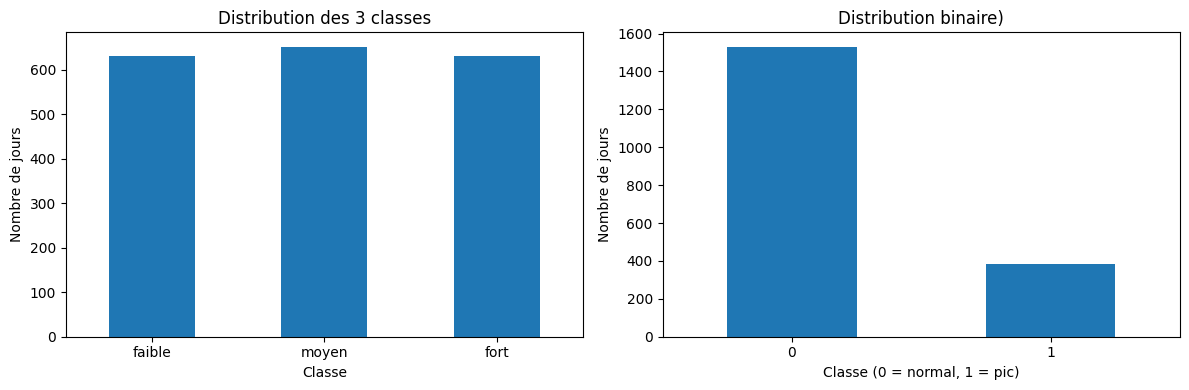

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3 classes
daily["classe"].value_counts().reindex(["faible", "moyen", "fort"]).plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribution des 3 classes")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Nombre de jours")
axes[0].tick_params(axis="x", rotation=0)

# Binaire
seuil_pic = daily["sales"].quantile(0.80)
daily["pic"] = (daily["sales"] >= seuil_pic).astype(int)
daily["pic"].value_counts().plot(kind="bar", ax=axes[1],)
axes[1].set_title(f"Distribution binaire)")
axes[1].set_xlabel("Classe (0 = normal, 1 = pic)")
axes[1].set_ylabel("Nombre de jours")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Train Test Split

In [23]:
features = [
    "dayofweek", 
    "month",
    "lag_1",
    "lag_7",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7"]

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

X_train = train[features]
X_test = test[features]

print("Train :", train.shape, "| Test :", test.shape)

Train : (1530, 11) | Test : (383, 11)


---

## Classification 3 classes (Random Forest)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily["classe_enc"] = le.fit_transform(daily["classe"])

split = int(len(daily) * 0.8)
train = daily.iloc[:split]
test  = daily.iloc[split:]

y_train_3 = train["classe_enc"]
y_test_3 = test["classe_enc"]

clf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_3.fit(X_train, y_train_3)
pred_3 = clf_3.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test_3, pred_3), 4))
print(classification_report(y_test_3, pred_3, target_names=le.classes_))

Accuracy : 0.7833
              precision    recall  f1-score   support

      faible       0.70      0.41      0.52        17
        fort       0.95      0.73      0.83       231
       moyen       0.63      0.93      0.75       135

    accuracy                           0.78       383
   macro avg       0.76      0.69      0.70       383
weighted avg       0.83      0.78      0.79       383



Le Random Forest prédit correctement environ 3 cas sur 4, ce qui est plutot bon.

Cependant, les performances sont différentes selon les classes. La classe forte demande est la plus représenté dans les données de test (231 jours) et obtient de bons résultats avec un recall de 0.73. La classe moyenne est bien détectée avec un recall de 0.93 mais elle est parfois confondue avec les classes voisines. Enfin, la classe faible  contient très peu d'exemples (17 jours) ce qui rend son évaluation moins précise. Le modèle différencie donc globalement bien les niveaux de demandes mais confond un peu les classes proches.

### Matrice de confusion pour le Random Forest

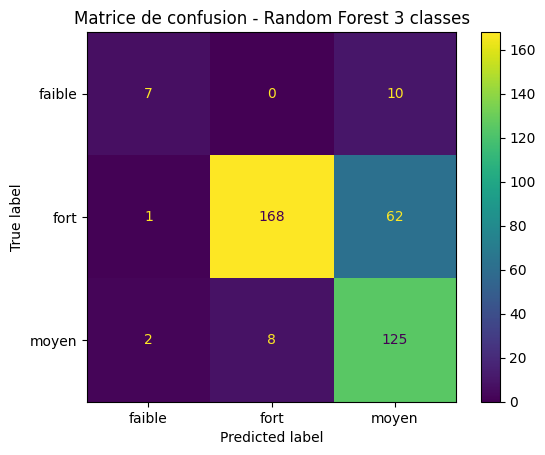

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test_3, pred_3, display_labels=le.classes_)

plt.title("Matrice de confusion - Random Forest 3 classes")
plt.show()

La matrice de confusion confirme que la classe 'fort' est très bien identifiée mais que le modèle confond fréquemment 'moyen' et 'fort'. 

Par ailleurs, on constate aussi que le modèle à tendance à confondre la classe vraie avec la classe la plus proche (ex : 'faible' avec 'moyen', 'fort' avec 'moyen' et 'moyen' avec 'faible'), ce qui est plutot positif car cela montre qu'il différencie relativement bien les niveaux extrêmes et confond principalement les classes voisines.

---

## Transformation en modèle binaire

Nous allons maintenant voir s'il serait plus intéressant ou pas de transformer le problème en problème binaire. 0 représente une période normale et 1 représente un pic. Avec ce modèle, nous pourrions donc prédire les situations à risque ou les situations normales.

Accuracy : 0.8903
              precision    recall  f1-score   support

      Normal       0.87      0.98      0.92       246
         Pic       0.95      0.73      0.83       137

    accuracy                           0.89       383
   macro avg       0.91      0.85      0.87       383
weighted avg       0.90      0.89      0.89       383



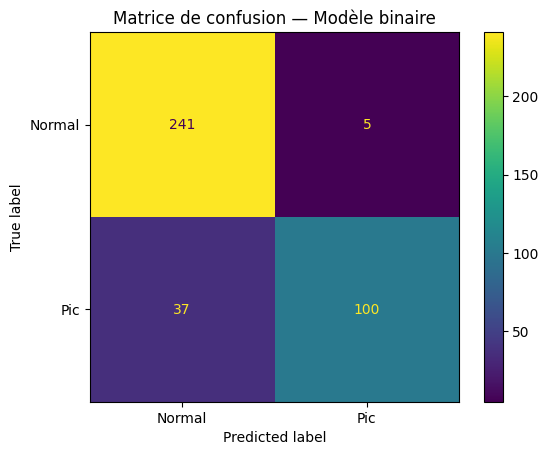

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

y_train_binaire = train["pic"]
y_test_binaire = test["pic"]

clf_binaire = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_binaire.fit(X_train, y_train_binaire)
pred_binaire = clf_binaire.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test_binaire, pred_binaire), 4))
print(classification_report(y_test_binaire, pred_binaire, target_names=["Normal", "Pic"]))

# Matrice de confusion — modèle binaire
ConfusionMatrixDisplay.from_predictions(y_test_binaire, pred_binaire, display_labels=["Normal", "Pic"])

plt.title("Matrice de confusion — Modèle binaire")
plt.show()

L'accuracy du modèle binaire est très bonne (0.89). On note quand même qu'il y a plus de données de classe 0 donc l'accuracy est très élevée aussi parce que le modèle considère qu'il a bien appris car il réussit dans 98% des cas à prédire la classe 0, mais lorsqu'on regarde la classe 1, on se rend compte qu'il tombe à 73% de bonne prédiction de pics. Les scores sont quand même très bon et ce modèle semble mieux que le précédent pour détecter des pics.

---

## Conclusion

Nous avons comparé plusieurs approches de classification afin de prédire les niveaux de demande et identifier les périodes à risque pour la supply chain.

Le modèle Random Forest à 3 classes obtient une accuracy d’environ 78%. Il parvient globalement à distinguer les différentes classes, même s'il confond parfois les classes proches.

Le modèle binaire, obtient les meilleurs résultats globaux avec une accuracy de 89% et un recall de 73% sur la classe des pics.

In [28]:
from sklearn.metrics import recall_score, f1_score

resultats_classif = pd.DataFrame({
    "Modèle": [
        "3 classes sans rééquilibrage",
        "Binaire avec quantile à 80%"
    ],
    "Accuracy": [
        round(accuracy_score(y_test_3, pred_3),  4),
        round(accuracy_score(y_test_binaire, pred_binaire),4)
    ],
    "Recall classe forte / pic": [
        round(recall_score(y_test_3, pred_3,  average=None)[le.transform(["fort"])[0]], 4),
        round(recall_score(y_test_binaire, pred_binaire, pos_label=1), 4)
    ],
    "F1 macro": [
        round(f1_score(y_test_3, pred_3,  average="macro"), 4),
        round(f1_score(y_test_binaire, pred_binaire, average="macro"), 4)
    ]
})

print(resultats_classif.to_string(index=False))

                      Modèle  Accuracy  Recall classe forte / pic  F1 macro
3 classes sans rééquilibrage    0.7833                     0.7273    0.6990
 Binaire avec quantile à 80%    0.8903                     0.7299    0.8731


---

## Export du modèle binaire pour Streamlit

In [29]:
import joblib

clf_binaire_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
clf_binaire_final.fit(daily[features], daily["pic"])

joblib.dump(clf_binaire_final, "modele_classification_global.pkl")
joblib.dump(seuil_pic, "seuil_pic_global.pkl")

print("Modèle de classification sauvegardé.")

Modèle de classification sauvegardé.
